In [ ]:
# Реализация методов оптимизации SGD и Adam

# В данной работе исследуются различные методы оптимизации для обучения модели линейной регрессии при решении задачи прогнозирования стоимости квартир.

# Рассматриваются следующие методы:
# SGD (Stochastic Gradient Descent)
# Adam.

# Также исследуется влияние регуляризации:
# L1-регуляризации
# L2-регуляризации.

# Сравнение методов производится по значениям функции ошибки MSE, RMSE и коэффициента детерминации R².

In [2]:
import csv
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12

In [3]:
# Общие функции
def gradient(w, b,   data, number_of_sings=19):
    grad = [0 for i in range(number_of_sings)]#градиент
    gradb = 0#градиент свободного члена
    for i in range(len(data)):
        pred = b
        for j in range(number_of_sings):
            pred += w[j]*data[i][j]
        err = pred - data[i][-1]
        for j in range(number_of_sings):
            grad[j] += err*data[i][j]*2
        gradb += err*2
        #считаем градиент по каждой квартире и складываем потом усредним
    for i in range(number_of_sings):
        grad[i] /= len(data)#усредняем
    gradb /= len(data)
    return grad, gradb#возвращает градиент по перменным и градиент по свободному члену отдельно

def data_normalized(list_dt, mean=None, std=None):
    if mean is None or std is None:#считаем среднее на тренировочных данных
        mean = [0 for i in range(len(list_dt[0])-1)]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i])-1):
                mean[j] += list_dt[i][j]
        for i in range(len(mean)):
            mean[i] /= len(list_dt)
        std = [0 for i in range(len(mean))]
        for i in range(len(list_dt)):
            for j in range(len(list_dt[i])-1):
                std[j] += (list_dt[i][j] - mean[j])**2
        for i in range(len(std)):
            std[i] /= len(list_dt)
            std[i] = std[i] ** 0.5
    else:#если поданы просто присваеваем без вычислений
        mean = mean
        std = std
    new_list_dt = []
    for i in range(len(list_dt)):
        row_i = []
        for j in range(len(list_dt[i])-1):
            x_i_j = (list_dt[i][j]-mean[j])/std[j]#z-стандартизация превращает данные в числа от -1 до 1
            row_i.append(x_i_j)
        row_i.append(list_dt[i][-1])#добавляем целевую переменную
        new_list_dt.append(row_i)
    return new_list_dt, mean, std

def prev_csv(data):#функция переводит данные в список мне так проще хотя может и неэффективней
    list_data = []
    flag = 0
    for row in data:
        if flag == 0:
            flag+=1
        else:
            l = list(row)
            t = [float(i) for i in l]
            list_data.append(t)
    return list_data

def errors(data, v, b):
    mse = 0
    mn = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        err = data[i][-1] - pred
        mse += err * err
        mn += data[i][-1]
    mse /= len(data)
    rmse = mse ** 0.5

    mn /= len(data)
    ss_total = 0
    ss_res = 0
    for i in range(len(data)):
        pred = b
        for j in range(len(v)):
            pred += v[j] * data[i][j]
        ss_total += (mn - data[i][-1]) ** 2
        ss_res += (data[i][-1] - pred) ** 2

    r = 1 - ss_res / ss_total
    return mse, rmse, r

In [4]:
# Загрузка данных
file = open('dataset_sample_3000.csv', 'r')

train_data = csv.reader(file)

train_list_data = prev_csv(train_data)

file.close()

train_list_data, mean, std = data_normalized(train_list_data)

file = open('dataset_sample_5000.csv', 'r')

test_data = csv.reader(file)

test_list_data = prev_csv(test_data)

file.close()

test_list_data, mean, std = data_normalized(
    test_list_data,
    mean,
    std
)

In [ ]:
# Реализация стохастического градиентного спуска (SGD)

# Алгоритм SGD отличается от обычного градиентного спуска тем, что обновление весов производится после обработки каждого обучающего примера, а не после вычисления градиента по всему набору данных.

# Это позволяет быстрее сходиться на больших объемах данных и уменьшает затраты памяти.

In [5]:
def find_weight_sgd(
    data,
    number_of_epochs=30,
    learning_rate=0.0005
):

    # количество признаков
    number_of_signs = len(data[0]) - 1

    # веса
    w = [0.0 for _ in range(number_of_signs)]

    # свободный член
    b = sum(row[-1] for row in data) / len(data)

    # история ошибки
    mse_history = []

    for epoch in range(number_of_epochs):

        # перемешиваем данные
        random.shuffle(data)

        # проходим по каждой квартире
        for sample in data:

            # вычисляем градиент по одной квартире
            g, gb = gradient(w, b, [sample], number_of_signs)

            # обновляем веса
            for j in range(number_of_signs):
                w[j] -= learning_rate * g[j]

            # обновляем свободный член
            b -= learning_rate * gb

        # вычисляем MSE после эпохи
        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

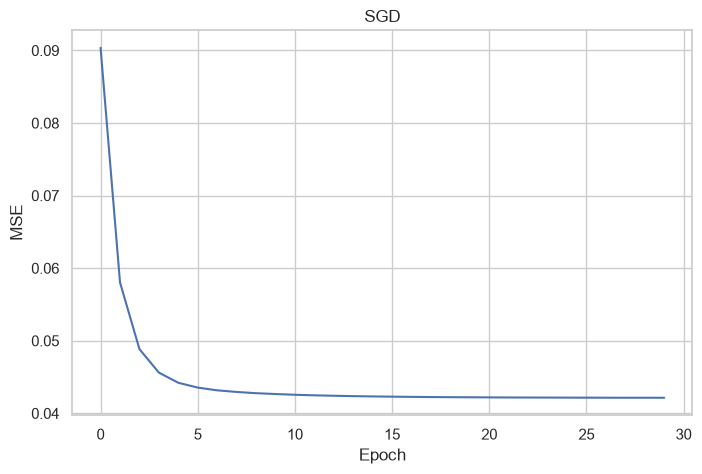

In [6]:
w_sgd, b_sgd, mse_history = find_weight_sgd(
    train_list_data,
    number_of_epochs=30,
    learning_rate=0.0001
)
mse_test, rmse_test, r_test = errors(
    test_list_data,
    w_sgd,
    b_sgd
)
plt.figure(figsize=(8,5))

plt.plot(mse_history)

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.title("SGD")

plt.grid(True)

plt.show()

In [ ]:
# При learning rate = 0.01 алгоритм демонстрировал нестабильную сходимость. После уменьшения шага до 0.0001 процесс обучения стал устойчивым, а значение функции потерь начало монотонно уменьшаться.

In [ ]:
# SGD с L2-регуляризацией

# Для борьбы с переобучением используется L2-регуляризация.

# К функции потерь добавляется штраф за большие значения весов:

# L = MSE + λ Σ(wᵢ²)

# Параметр λ определяет силу регуляризации. Чем больше λ, тем сильнее модель стремится уменьшать веса.
#То есть к градиенту добавляется: 2 * lambda_ * w[j]

In [7]:
#Код SGD + L2

def find_weight_sgd_l2(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    lambda_=0.01
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]

    b = sum(row[-1] for row in data) / len(data)

    mse_history = []

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                w[j] -= learning_rate * (
                    g[j] + 2 * lambda_ * w[j]
                )

            b -= learning_rate * gb

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

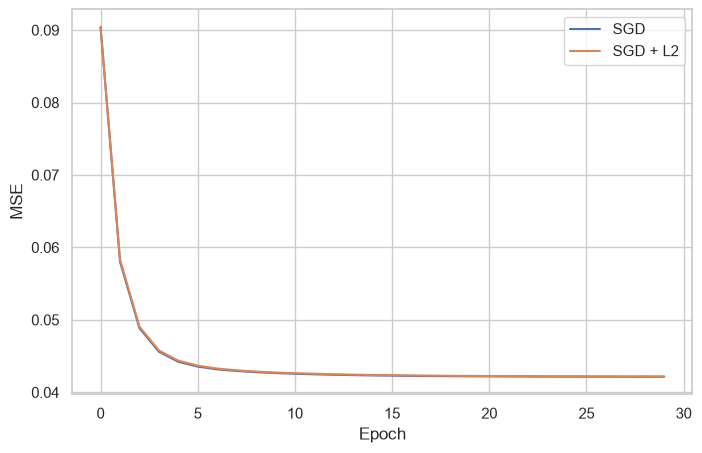

In [8]:
w_l2, b_l2, mse_l2 = find_weight_sgd_l2(
    train_list_data,
    learning_rate=0.0001,
    lambda_=0.01
)

plt.figure(figsize=(8,5))

plt.plot(mse_history, label="SGD")

plt.plot(mse_l2, label="SGD + L2")

plt.xlabel("Epoch")
plt.ylabel("MSE")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Вывод по L2-регуляризации

# После добавления L2-регуляризации существенных изменений в процессе обучения не наблюдалось. График изменения функции потерь практически совпадает с графиком обычного SGD, а качество модели изменилось незначительно.

# Это можно объяснить тем, что выбранное значение параметра регуляризации λ оказалось небольшим, поэтому влияние штрафа на веса модели было слабым. Тем не менее использование L2-регуляризации позволяет ограничивать рост коэффициентов модели и снижает вероятность переобучения при обучении на больших наборах данных.

In [ ]:
# SGD с L1-регуляризацией

# L1-регуляризация также используется для борьбы с переобучением, однако в отличие от L2 она добавляет штраф, пропорциональный сумме модулей весов модели.

# Функция потерь принимает вид:
# L = MSE + λ Σ|wᵢ|

# L1-регуляризация способствует занулению некоторых коэффициентов модели, благодаря чему происходит автоматический отбор наиболее значимых признаков.

In [9]:
# Код SGD + L1

def find_weight_sgd_l1(
    data,
    number_of_epochs=30,
    learning_rate=0.0005,
    lambda_=0.001
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]

    b = sum(row[-1] for row in data) / len(data)

    mse_history = []

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                # знак веса
                if w[j] > 0:
                    reg = lambda_
                elif w[j] < 0:
                    reg = -lambda_
                else:
                    reg = 0

                w[j] -=learning_rate * (g[j] + reg)

            b -= learning_rate * gb

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

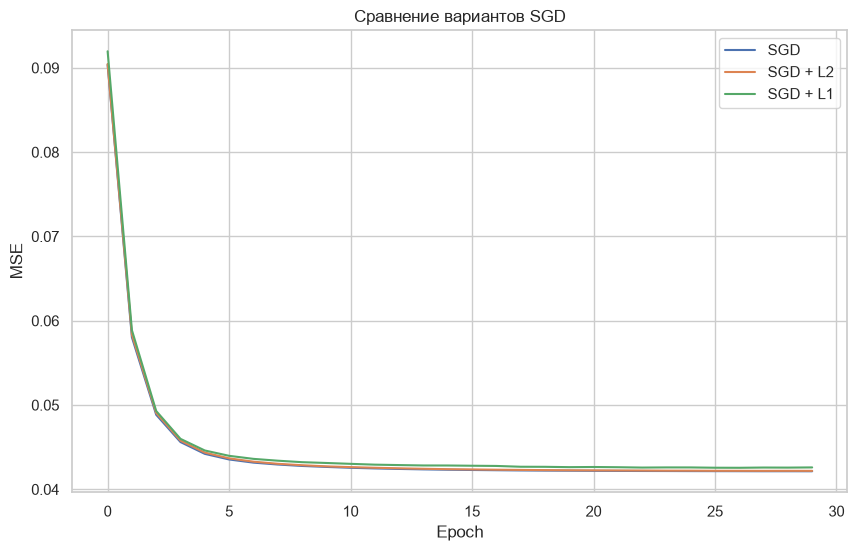

In [10]:
w_l1, b_l1, mse_l1 = find_weight_sgd_l1(
    train_list_data,
    learning_rate=0.0001,
    lambda_=0.01
)
errors(
    test_list_data,
    w_l1,
    b_l1
)
plt.figure(figsize=(10,6))

plt.plot(mse_history, label="SGD")

plt.plot(mse_l2, label="SGD + L2")

plt.plot(mse_l1, label="SGD + L1")

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.title("Сравнение вариантов SGD")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
# Вывод

# Добавление L1-регуляризации также не привело к существенному изменению поведения алгоритма при выбранном значении параметра λ. Процесс обучения оставался стабильным, а значения функции потерь были близки к результатам обычного SGD.

In [ ]:
# Общий вывод по SGD

# В ходе работы были реализованы три варианта стохастического градиентного спуска:

# классический SGD;
# SGD с L2-регуляризацией;
# SGD с L1-регуляризацией.

# Во всех случаях алгоритм успешно сходился при правильно подобранном значении скорости обучения. Наиболее существенное влияние на стабильность обучения оказал параметр learning rate. При слишком большом значении наблюдались колебания функции потерь, тогда как уменьшение шага обучения обеспечило устойчивую сходимость.

# Использование L1- и L2-регуляризации при выбранных значениях λ не оказало значительного влияния на качество модели. Однако данные методы являются важными инструментами борьбы с переобучением и могут давать заметный эффект при обучении на более сложных выборках или при других значениях параметра регуляризации.

In [ ]:
# Реализация метода Adam

# В отличие от обычного SGD, Adam автоматически подбирает шаг обучения для каждого параметра модели отдельно.

# Алгоритм использует две оценки:
# первый момент (среднее значение градиента);
# второй момент (среднее значение квадрата градиента).

# Это позволяет сделать обучение более стабильным и ускорить сходимость модели.

In [11]:
# Код метода Adam

import math

def find_weight_adam(
    data,
    number_of_epochs=30,
    learning_rate=0.0001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]
    b = sum(row[-1] for row in data) / len(data)

    # первый момент
    m = [0.0 for _ in range(number_of_signs)]

    # второй момент
    v = [0.0 for _ in range(number_of_signs)]

    # для свободного члена
    m_b = 0.0
    v_b = 0.0

    mse_history = []

    t = 0

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            t += 1

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                # первый момент
                m[j] = beta1 * m[j] + (1 - beta1) * g[j]

                # второй момент
                v[j] = beta2 * v[j] + (1 - beta2) * (g[j] ** 2)

                # коррекция смещения
                m_hat = m[j] / (1 - beta1 ** t)
                v_hat = v[j] / (1 - beta2 ** t)

                # обновление веса
                w[j] -= learning_rate * m_hat / (math.sqrt(v_hat) + epsilon)

            # свободный член

            m_b = beta1 * m_b + (1 - beta1) * gb
            v_b = beta2 * v_b + (1 - beta2) * (gb ** 2)

            m_hat_b = m_b / (1 - beta1 ** t)
            v_hat_b = v_b / (1 - beta2 ** t)

            b -= learning_rate * m_hat_b / (math.sqrt(v_hat_b) + epsilon)

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

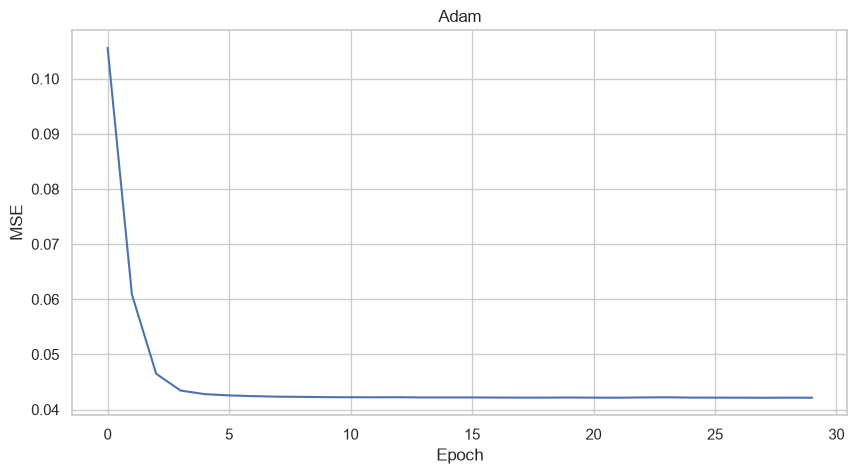

In [12]:
w_adam, b_adam, mse_adam = find_weight_adam(
    train_list_data
)
errors(
    test_list_data,
    w_adam,
    b_adam
)
plt.figure(figsize=(10,5))

plt.plot(mse_adam)

plt.xlabel("Epoch")

plt.ylabel("MSE")

plt.title("Adam")

plt.grid(True)

plt.show()

In [69]:
# Adam с L2-регуляризацией

# В этом случае обновление весов производится с учетом дополнительного штрафа, пропорционального квадрату величины каждого коэффициента модели.

In [13]:
# Реализация Adam + L2

def find_weight_adam_l2(
    data,
    number_of_epochs=30,
    learning_rate=0.0001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    lambda_=0.01
):

    number_of_signs = len(data[0]) - 1

    w = [0.0 for _ in range(number_of_signs)]
    b = sum(row[-1] for row in data) / len(data)

    m = [0.0 for _ in range(number_of_signs)]
    v = [0.0 for _ in range(number_of_signs)]

    m_b = 0.0
    v_b = 0.0

    mse_history = []

    t = 0

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            t += 1

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                m[j] = beta1 * m[j] + (1 - beta1) * g[j]
                v[j] = beta2 * v[j] + (1 - beta2) * g[j] ** 2

                m_hat = m[j] / (1 - beta1 ** t)
                v_hat = v[j] / (1 - beta2 ** t)

                w[j] -= learning_rate * (
                    m_hat / (math.sqrt(v_hat) + epsilon)
                    + 2 * lambda_ * w[j]
                )

            m_b = beta1 * m_b + (1 - beta1) * gb
            v_b = beta2 * v_b + (1 - beta2) * gb ** 2

            m_hat_b = m_b / (1 - beta1 ** t)
            v_hat_b = v_b / (1 - beta2 ** t)

            b -= learning_rate * m_hat_b / (math.sqrt(v_hat_b) + epsilon)

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

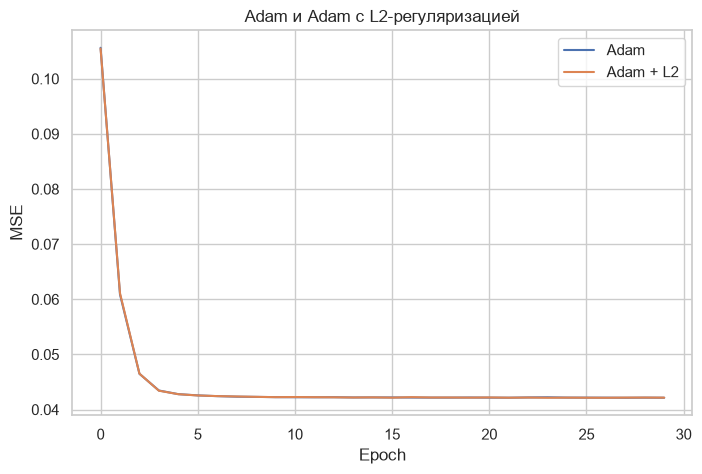

In [14]:
w_adam_l2, b_adam_l2, mse_adam_l2 = find_weight_adam_l2(
    train_list_data,
    lambda_=0.0005
)
errors(
    test_list_data,
    w_adam_l2,
    b_adam_l2
)
plt.figure(figsize=(8,5))

plt.plot(mse_adam, label="Adam")

plt.plot(mse_adam_l2, label="Adam + L2")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Adam и Adam с L2-регуляризацией")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Вывод

# Добавление L2-регуляризации практически не изменило характер сходимости алгоритма Adam. Графики изменения функции потерь имеют схожую форму, а итоговые значения ошибки отличаются незначительно, хотя график Adam+L2 ведет себя более стабильно. Использование L2 позволяет ограничивать рост коэффициентов модели и снижать вероятность переобучения.

In [ ]:
# Adam с L1-регуляризацией

# L1-регуляризация добавляет к функции потерь сумму модулей коэффициентов модели.

# В отличие от L2-регуляризации, данный метод способен уменьшать отдельные веса до нулевых значений, тем самым автоматически выполняя отбор наиболее значимых признаков.

In [15]:
# Реализация Adam + L1

def find_weight_adam_l1(
    data,
    number_of_epochs=30,
    learning_rate=0.0001,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8,
    lambda_=0.001
):

    number_of_signs = len(data[0]) - 1

    # Веса модели
    w = [0.0 for _ in range(number_of_signs)]
    b = sum(row[-1] for row in data) / len(data)

    # Первый момент
    m = [0.0 for _ in range(number_of_signs)]

    # Второй момент
    v = [0.0 for _ in range(number_of_signs)]

    # Для свободного члена
    m_b = 0.0
    v_b = 0.0

    mse_history = []

    t = 0

    for epoch in range(number_of_epochs):

        random.shuffle(data)

        for sample in data:

            t += 1

            g, gb = gradient(w, b, [sample], number_of_signs)

            for j in range(number_of_signs):

                # Первый момент
                m[j] = beta1 * m[j] + (1 - beta1) * g[j]

                # Второй момент
                v[j] = beta2 * v[j] + (1 - beta2) * (g[j] ** 2)

                # Коррекция смещения
                m_hat = m[j] / (1 - beta1 ** t)
                v_hat = v[j] / (1 - beta2 ** t)

                # L1-регуляризация
                if w[j] > 0:
                    reg = lambda_
                elif w[j] < 0:
                    reg = -lambda_
                else:
                    reg = 0

                # Обновление веса
                w[j] -= learning_rate * (
                    m_hat / (math.sqrt(v_hat) + epsilon)
                    + reg
                )

            # Обновление свободного члена

            m_b = beta1 * m_b + (1 - beta1) * gb
            v_b = beta2 * v_b + (1 - beta2) * (gb ** 2)

            m_hat_b = m_b / (1 - beta1 ** t)
            v_hat_b = v_b / (1 - beta2 ** t)

            b -= learning_rate * (
                m_hat_b / (math.sqrt(v_hat_b) + epsilon)
            )

        mse, _, _ = errors(data, w, b)
        mse_history.append(mse)

    return w, b, mse_history

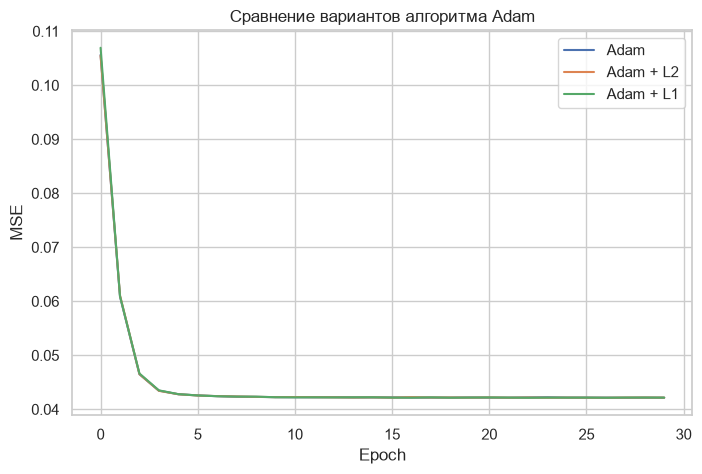

In [16]:
w_adam_l1, b_adam_l1, mse_adam_l1 = find_weight_adam_l1(
    train_list_data,
    lambda_=0.0005
)
errors(
    test_list_data,
    w_adam_l1,
    b_adam_l1
)
plt.figure(figsize=(8,5))

plt.plot(mse_adam, label="Adam")

plt.plot(mse_adam_l2, label="Adam + L2")

plt.plot(mse_adam_l1, label="Adam + L1")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Сравнение вариантов алгоритма Adam")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
# Вывод

# Добавление L1-регуляризации также не оказало существенного влияния на скорость сходимости алгоритма Adam при выбранном значении λ. Поведение функции потерь осталось практически таким же, как у базового алгоритма.

In [ ]:
# Общий вывод по Adam

# В ходе работы были реализованы три варианта алгоритма Adam:
# Adam;
# Adam с L2-регуляризацией;
# Adam с L1-регуляризацией.

# Во всех проведённых экспериментах алгоритм Adam продемонстрировал устойчивую сходимость и плавное уменьшение функции потерь. Добавление L1- и L2-регуляризации не оказало существенного влияния на качество модели при выбранных значениях параметра λ, однако данные методы позволяют уменьшить риск переобучения и могут давать более заметный эффект при обучении на более сложных наборах данных.

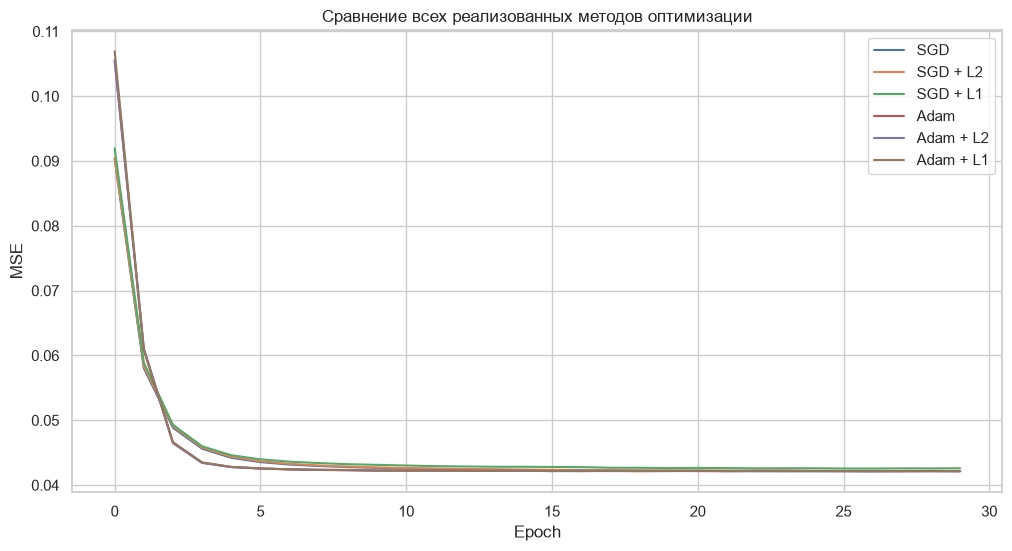

In [17]:
# Результат

plt.figure(figsize=(12,6))

plt.plot(mse_history, label="SGD")

plt.plot(mse_l2, label="SGD + L2")

plt.plot(mse_l1, label="SGD + L1")

plt.plot(mse_adam, label="Adam")

plt.plot(mse_adam_l2, label="Adam + L2")

plt.plot(mse_adam_l1, label="Adam + L1")

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Сравнение всех реализованных методов оптимизации")

plt.grid(True)
plt.legend()

plt.show()

In [18]:
# SGD
mse_sgd, rmse_sgd, r2_sgd = errors(test_list_data, w_sgd, b_sgd)

# SGD + L2
mse_sgd_l2, rmse_sgd_l2, r2_sgd_l2 = errors(test_list_data, w_l2, b_l2)

# SGD + L1
mse_sgd_l1, rmse_sgd_l1, r2_sgd_l1 = errors(test_list_data, w_l1, b_l1)

# Adam
mse_adam_res, rmse_adam, r2_adam = errors(test_list_data, w_adam, b_adam)

# Adam + L2
mse_adam_l2_res, rmse_adam_l2, r2_adam_l2 = errors(test_list_data, w_adam_l2, b_adam_l2)

# Adam + L1
mse_adam_l1_res, rmse_adam_l1, r2_adam_l1 = errors(test_list_data, w_adam_l1, b_adam_l1)

results = pd.DataFrame({

    "Метод":[
        "SGD",
        "SGD + L2",
        "SGD + L1",
        "Adam",
        "Adam + L2",
        "Adam + L1"
    ],

    "MSE":[
        mse_sgd,
        mse_sgd_l2,
        mse_sgd_l1,
        mse_adam_res,
        mse_adam_l2_res,
        mse_adam_l1_res
    ],

    "RMSE":[
        rmse_sgd,
        rmse_sgd_l2,
        rmse_sgd_l1,
        rmse_adam,
        rmse_adam_l2,
        rmse_adam_l1
    ],

    "R²":[
        r2_sgd,
        r2_sgd_l2,
        r2_sgd_l1,
        r2_adam,
        r2_adam_l2,
        r2_adam_l1
    ]

})

results

,Метод,MSE,RMSE,R²
0,SGD,0.042063,0.205093,0.842102
1,SGD + L2,0.042103,0.205190,0.841953
2,SGD + L1,0.042622,0.206451,0.840003
3,Adam,0.042117,0.205224,0.841900
4,Adam + L2,0.042086,0.205149,0.842016
5,Adam + L1,0.042130,0.205256,0.841850


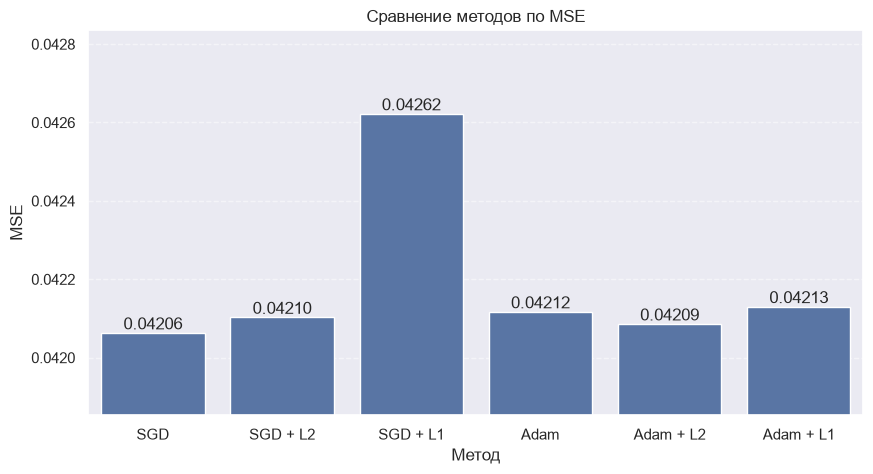

In [19]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=results,
    x="Метод",
    y="MSE"
)

ymin = results["MSE"].min()
ymax = results["MSE"].max()

plt.ylim(ymin * 0.995, ymax * 1.005)

for container in ax.containers:
    ax.bar_label(container, fmt="%.5f")

plt.title("Сравнение методов по MSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

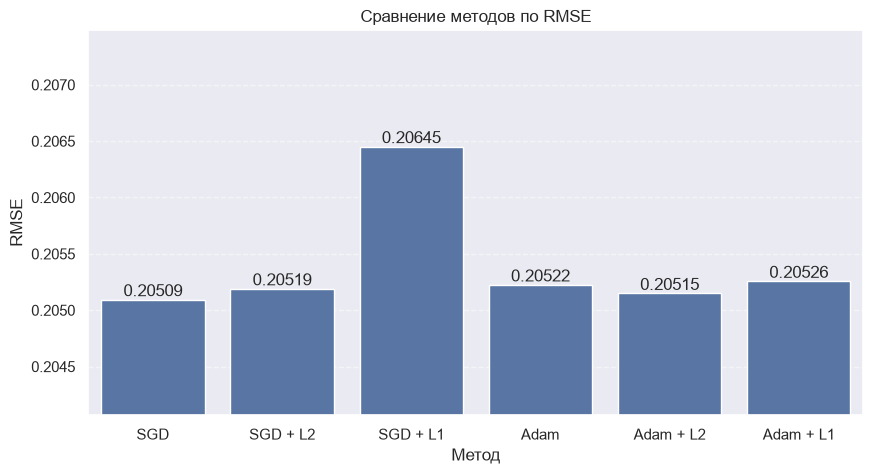

In [20]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=results,
    x="Метод",
    y="RMSE"
)
ymin = results["RMSE"].min()
ymax = results["RMSE"].max()

plt.ylim(ymin * 0.995, ymax * 1.005)

for container in ax.containers:
    ax.bar_label(container, fmt="%.5f")

plt.title("Сравнение методов по RMSE")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

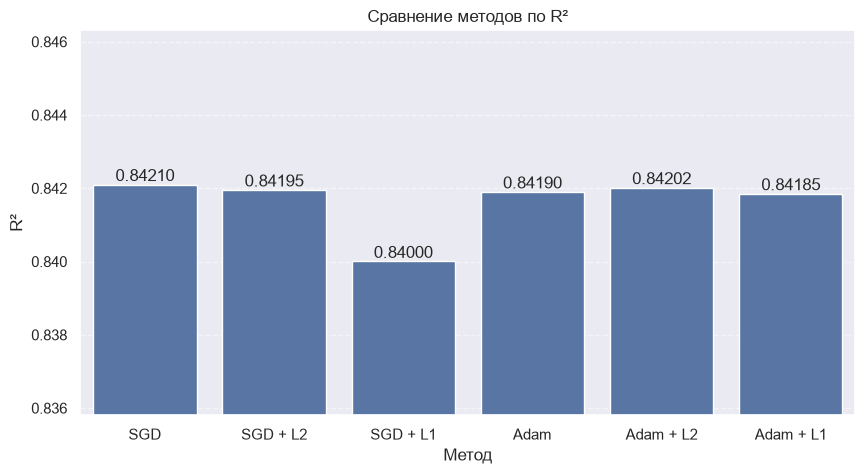

In [21]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    data=results,
    x="Метод",
    y="R²"
)

ymin = results["R²"].min()
ymax = results["R²"].max()

plt.ylim(ymin * 0.995, ymax * 1.005)

for container in ax.containers:
    ax.bar_label(container, fmt="%.5f")
plt.title("Сравнение методов по R²")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [22]:
best = results.loc[results["MSE"].idxmin()]

print(f"Лучший метод: {best['Метод']}")
print(f"MSE = {best['MSE']}")
print(f"RMSE = {best['RMSE']}")
print(f"R² = {best['R²']}")

Лучший метод: SGD
MSE = 0.042063238718362234
RMSE = 0.20509324396079515
R² = 0.8421015030893118


In [ ]:
# Итоговое сравнение методов

# В результате проведённых экспериментов были сравнены шесть вариантов алгоритмов оптимизации:

# SGD;
# SGD с L2-регуляризацией;
# SGD с L1-регуляризацией;
# Adam;
# Adam с L2-регуляризацией;
# Adam с L1-регуляризацией.

# Сравнение проводилось по следующим метрикам качества:

# MSE (Mean Squared Error) - среднеквадратичная ошибка;
# RMSE (Root Mean Squared Error) - корень из среднеквадратичной ошибки;
# R² (коэффициент детерминации) - показывает, насколько хорошо модель объясняет данные.

# Полученные результаты показали, что использование регуляризации позволяет контролировать сложность модели и уменьшать вероятность переобучения.

# L2-регуляризация уменьшает значения весовых коэффициентов, но не зануляет их полностью. Благодаря этому сохраняется вклад всех признаков, однако влияние менее значимых становится значительно слабее.

# L1-регуляризация, напротив, способна занулять веса неинформативных признаков, фактически исключая их из модели. Это позволяет автоматически выполнять отбор наиболее важных признаков и получать более интерпретируемую модель.

# На основании полученных результатов можно определить наиболее эффективный алгоритм для рассматриваемого набора данных и оценить влияние различных методов оптимизации и регуляризации на качество прогнозирования стоимости квартир.